In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

Let's set some constants, default clusters number to 3, features

In [18]:
DATA_PATH = "../datasets/Mall_Customers.csv"
RANDOM_STATE = 13
N_CLUSTERS = 3

FEATURES = ["Age", "Annual Income (k$)", "Spending Score (1-100)", "Gender"]

In [12]:
data = pd.read_csv(DATA_PATH)

display(data.shape)
display(data.head())
data.info()
display(data.isna().sum())

(200, 5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Converting gender to numeric value

In [6]:
data["Gender"] = data["Gender"].map({"Female": 0, "Male": 1})

X = data[FEATURES].copy()

Scaling is important for KMeans

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Training model

In [19]:
kmeans = KMeans(
    n_clusters=N_CLUSTERS, init="k-means++", n_init=10, random_state=RANDOM_STATE
)

kmeans.fit(X_scaled)

labels = kmeans.labels_
centers_scaled = kmeans.cluster_centers_
inertia = kmeans.inertia_

print(f"{inertia=}")
print("silhouette_score =", silhouette_score(X_scaled, labels))

inertia=476.7875544135159
silhouette_score = 0.25951265087431563


Let's build graph which shows inertias under different k values.

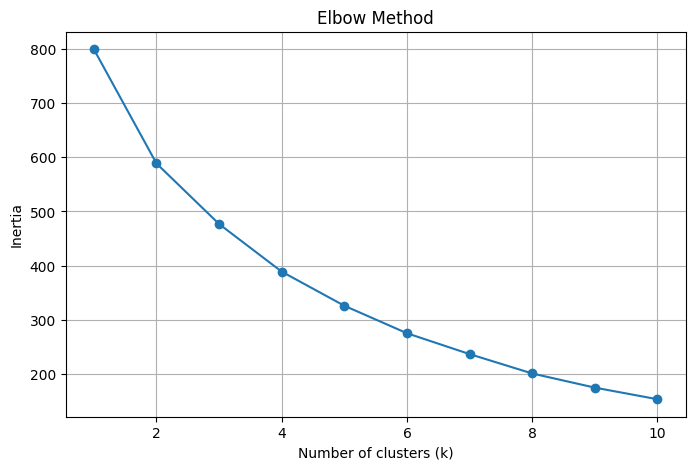

In [21]:
k_values = range(1, 11)
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

We can not tell much from the Elbow method, no visible elbow.
Let's check silhouete score with different cluster numbers.

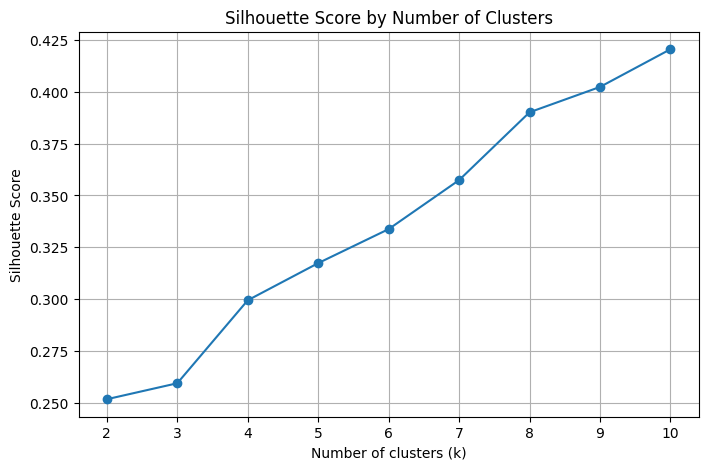

In [22]:
k_values = range(2, 11)
sil_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    cluster_labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    sil_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_values, sil_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.grid(True)
plt.show()

From the graph above we can see that optimal number of clusters is 4, cause it gives a spike in silhouette score.
Let's train model with updated k.

In [24]:
kmeans = KMeans(n_clusters=4, init="k-means++", n_init=10, random_state=RANDOM_STATE)

kmeans.fit(X_scaled)

labels = kmeans.labels_
centers_scaled = kmeans.cluster_centers_
inertia = kmeans.inertia_

Cause we have more 4 features, lets use PCA method to reduce them to 2.
That way we can visualize it on 2D graph.

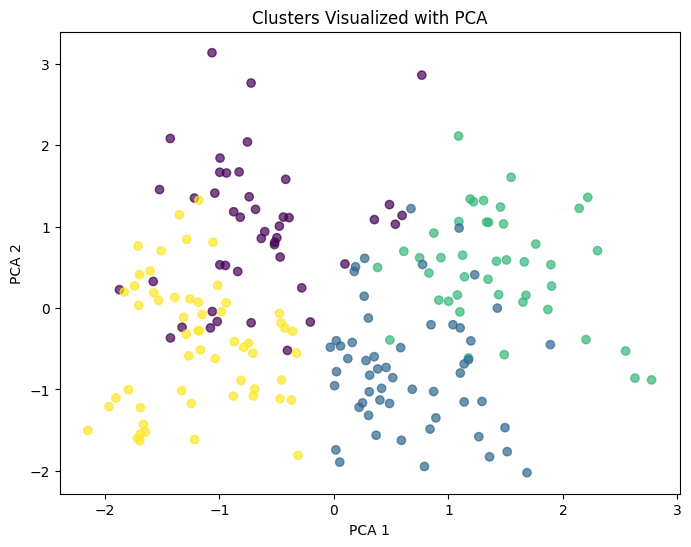

In [26]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, alpha=0.7)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Clusters Visualized with PCA")
plt.show()

Dots form well-separated areas on the graph, we can call clustering successful

More detailed cluster separation visualization

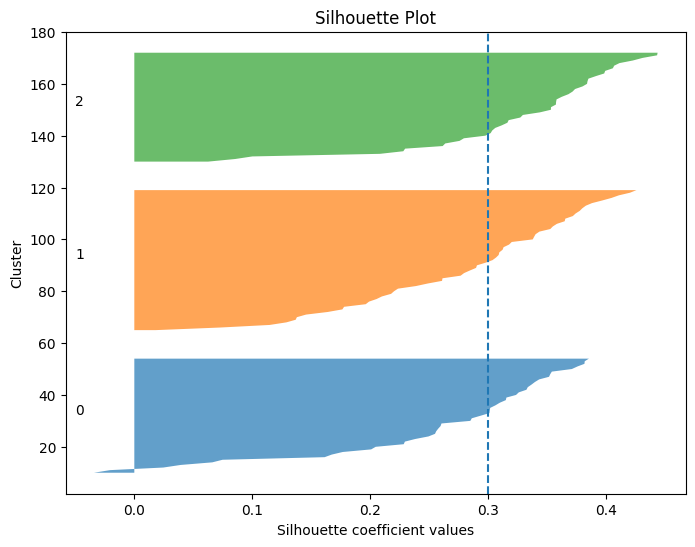

In [27]:
sample_silhouette_values = silhouette_samples(X_scaled, labels)

plt.figure(figsize=(8, 6))
y_lower = 10

for cluster_id in range(N_CLUSTERS):
    cluster_silhouette_vals = sample_silhouette_values[labels == cluster_id]
    cluster_silhouette_vals.sort()

    size_cluster = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster

    plt.fill_betweenx(
        np.arange(y_lower, y_upper), 0, cluster_silhouette_vals, alpha=0.7
    )

    plt.text(-0.05, y_lower + 0.5 * size_cluster, str(cluster_id))
    y_lower = y_upper + 10

plt.axvline(x=silhouette_score(X_scaled, labels), linestyle="--")
plt.xlabel("Silhouette coefficient values")
plt.ylabel("Cluster")
plt.title("Silhouette Plot")
plt.show()

Table with data and clusters

In [ ]:
results = X.copy()
results["cluster"] = labels

display(results.head())
display(results["cluster"].value_counts().sort_index())

,Age,Annual Income (k$),Spending Score (1-100),Gender,cluster
0,19,15,39,1,0
1,21,15,81,1,0
2,20,16,6,0,1
3,23,16,77,0,3
4,31,17,40,0,3


cluster
0    45
1    55
2    43
3    57
Name: count, dtype: int64